# Test the Model & Visualize it 
Now the model is craeted an trained. So let's use it testwise. Idea would be to 
- be able to run it - since it works on the daily candle - on a daily base
- store the outcome of the test in a table to be able to 
- visualize it

In [42]:
# here we convert the jupiter file to a python script since it is easier to handle 
!jupyter nbconvert --to script --output test_the_model test_the_model.ipynb

[NbConvertApp] Converting notebook test_the_model.ipynb to script
/workspaces/candle-stick-reinfordement-based/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id '1a36187e' detected. Corrected to '7fe28e78'.
  validate(nb)
/workspaces/candle-stick-reinfordement-based/.venv/lib/python3.11/site-packages/nbformat/__init__.py:96: DuplicateCellId: Non-unique cell id 'a8fb6a48' detected. Corrected to 'eebd27ec'.
  validate(nb)
[NbConvertApp] Writing 9069 bytes to test_the_model.py


## Basic Libraries
Let's get the libs we need

In [43]:
import pandas as pd
import numpy as np
import os
import joblib

from stable_baselines3 import PPO
from supporting_classes import TradingEnv, OHLCScaler

We also need the data to play with

In [44]:
# at first, get a bit of data to play with
# Load raw data
data = pd.read_csv('../data/Candlestick_01nov1999_28oct2025.csv', parse_dates=['date'], index_col='date')

# Split into train/test again, now we only need the test data
split_idx  = int(len(data) * 0.8)
test_data  = data.iloc[split_idx:]

## Functions
Here I'd like to declare some functions to make things mor visible

### get_todays_outcome()
This function will return the OHLC-Volume data for the given date (+ the ammount of WINDOW_SIZE previous data points)   

In [45]:

# Grab into the test data and return the OHLC+Valume for the given (assuming todays) date
# INPUT: date_str - date as string in format 'YYYY-MM-DD'
# OUTPUT: panda series with OHLC+Valume for the given date in the form of
#           date          Open        High        Low         Close        Volume
#           2020-08-07    2.357494    2.386419    2.343762    2.382781    -0.739343
# OUTPUT: next_date - the next possible date fro trading
def get_todays_outcome(date_str, window_size=WINDOW_SIZE):
    # If the given date is not in the index, find the next available date
    if date_str not in data.index:
        print(f"Couldn't find date: {date_str}")
        # Find the next date in the index that is greater than the given date
        later_dates = data.index[data.index > date_str]
        if later_dates.empty:
            print("No later date available.")
            return None
        next_date = later_dates[0]
        print(f"Using next available date: {next_date}")
    else:
        # Get the index of the given date
        idx = data.index.get_loc(date_str)
        # Check if there is a next date available
        if idx + 1 >= len(data.index):
            print("No next date available.")
            return None
        next_date = data.index[idx + 1]

    # Get the index of the actual (available) date
    idx = data.index.get_loc(next_date)

    # Check if there is enough data before the selected date
    if idx < (window_size + 1):
        print(f"Not enough data before {next_date} for window_size={window_size}.")
        return None

    #print(f"Returning data for: {next_date}")
    # Return the sequence and the next available date. we need one more date the window size!!
    return data.iloc[idx - window_size - 1:idx], next_date

### do_one_step_and_make_prediction()
This function will do **ONE** step through the day

In [46]:
# This function does one step of action-prediction and returns the reward and new prediction
# INPUT: todays_predict - what was predicted for today (0 = HOLD, 1 = BUY, 2 = SELL)
# INPUT: todays_outcome - the actual OHLC+Volume data for today
# OUTPUT: new_reward - the reward received for the action taken
# OUTPUT: new_prediction - the new prediction for tomorrow (0 = HOLD, 1 = BUY, 2 = SELL)
def do_one_step_and_make_prediction(todays_predict, todays_outcome, window_size):
    
    scaled_df = scaler.transform(todays_outcome)                    # scale the data

    temp_env = TradingEnv(scaled_df, window_size=window_size)   # create a temporary environment for the given data
    obs, _ = temp_env.reset()                                   # reset the environment to get the initial observation

    new_prediction, _ = model.predict(obs)                              # use the model to predict the action based on the observation
    obs, reward, done, _, _ = temp_env.step(todays_predict)
    
    return reward, new_prediction

### calculate_stock_profit_loss()
This function will calculate the money gained or lost based on the given "reward"

In [47]:
# this fct will return the profit or loss of a day depending which bet were set and the ammount
# INPUT: predict - 0 = HOLD, 1 = BUY, 2 = SELL
# INPUT: date - provit of which date 
# OUTPUT: gain - the amount of money you lost or did win
# OUTPUT: change_percent - the change of the stock in percent
def calculate_stock_profit_loss(predict, date):
    row = data.loc[date]      # search for the correct row by date
    
    open_price = row['Open']
    close_price = row['Close']
    change_percent = ((close_price - open_price) / open_price) * 100

    
    if predict   == 1: # 'call'
        gain = BET_AMMOUNT * (change_percent / 100)
    elif predict == 2: #'put'
        gain = BET_AMMOUNT * (-change_percent / 100)
    elif predict == 0: #'hold'
        gain = 0
    else:
        raise ValueError("Ungültige Position: muss 'call', 'put' oder 'hold' sein.")
        gain = 0
    
    return gain, change_percent


### visualize_results()
This fct will visualize the given data

In [48]:

import matplotlib.pyplot as plt

def visualize_results(log_df):
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Linke Y-Achse: Bankkonto
    ax1.plot(log_df['Date'], log_df['Bank_Account'], color='blue', label='Bank Account')
    ax1.set_xlabel('Datum')
    ax1.set_ylabel('Bankkonto', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Rechte Y-Achse: Börsenkurs
    ax2 = ax1.twinx()
    ax2.plot(log_df['Date'], log_df['Closing_Price'], color='green', label='Dow Jones')
    ax2.set_ylabel('Börsenkurs', color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # Titel und Layout
    plt.title('Bankkonto vs. Börsenkurs')
    fig.tight_layout()
    plt.show()


###  def do_one_day():
**The Main Test Function**    
Whenever this block is called, it'll loop one day through the model and log + visualize the outcome

In [49]:
# Let's do one day. Lets get the values we found for todays date
def do_one_day():
    global todays_date, todays_predict, bank_account, log_df
   
    todays_outcome, next_days_date = get_todays_outcome(todays_date, WINDOW_SIZE)

    todays_reward, tomorrows_predict = do_one_step_and_make_prediction(todays_predict, todays_outcome, WINDOW_SIZE)

    profit_loss, perc_outcome   = calculate_stock_profit_loss(todays_predict, todays_date)
    bank_account += profit_loss

    # log it all
    new_row = {
        "Date": todays_date,
        "Predicted_Action": {0: 'HOLD', 1: 'BUY', 2: 'SELL'}[todays_predict.item()],
        "Closing_Price": todays_outcome['Close'].iloc[-1],  
        "Real_OutcomePerc": round(perc_outcome, 2),
        "Stock_Profit_Loss": profit_loss,
        "Bank_Account": bank_account
    }


    log_df = pd.concat([log_df, pd.DataFrame([new_row])], ignore_index=True)

    # print(log_df.tail())
    #print(log_df.to_string(index=False))


    todays_date    = next_days_date
    todays_predict = tomorrows_predict


# M A I N 

## Create some globals

In [64]:
WINDOW_SIZE = 50      # TODO: get this into a global variable
BET_AMMOUNT = 1000.0  # amount to invest per trade - assuming $ or € - same, same

# create the moste probable model name (model was stored with the last date of the training data)
filePath = f"../models/ppo_trading_{data.iloc[:split_idx].index[split_idx - 1].strftime('%Y_%m_%d')}.zip"

# check if the model exists
if os.path.exists(filePath):
    model = PPO.load(filePath)              # load the trained model
    print(f"Loading model from {filePath}") # state what we you did
else:       
    print(f"ERROR: Path {filePath} doesn't exist")
    print("ERROR:    ")
    print("ERROR:    Will terminate this execution!")
    exit()

# load the scaler for (re-)normalizing the data
scaler = joblib.load("../models/scaler.pkl")

# get some "gloabl" variables ready for later analysis and visualisation
nbr_of_test_dates = test_data.shape[0]  # how many test data do we have at all?
todays_date       = test_data.index[0]  # with which date shall we start? 
todays_predict    = np.array([0])       # (0 = HOLD, 1 = BUY, 2 = SELL)
bank_account      = 0.0                 # we starte with ZERO money on our account

log_df = pd.DataFrame({                 # here we create a pandas frame 
    "Date": pd.Series(dtype="str"),
    "Predicted_Action": pd.Series(dtype="str"),
    "Closing_Price":pd.Series(dtype="float"),
    "Real_OutcomePerc": pd.Series(dtype="str"),
    "Stock_Profit_Loss": pd.Series(dtype="float"),
    "Bank_Account": pd.Series(dtype="float")
})

print(f"Nbr of Testdata available: {nbr_of_test_dates}")
print(f"The Test will start at:    {todays_date.date()}")


Loading model from ../models/ppo_trading_2020_08_13.zip
Nbr of Testdata available: 1308
The Test will start at:    2020-08-14


## Run the loop

/tmp/ipykernel_13189/4125847066.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log_df = pd.concat([log_df, pd.DataFrame([new_row])], ignore_index=True)


      Date Predicted_Action  Closing_Price  Real_OutcomePerc  Stock_Profit_Loss  Bank_Account
2020-08-14             HOLD         279.80              0.56           0.000000      0.000000
2020-08-17             SELL         278.95             -0.42           4.247876      4.247876
2020-08-18             SELL         278.20             -0.32           3.224651      7.472527
2020-08-19              BUY         277.43             -0.45          -4.485431      2.987095
2020-08-20              BUY         277.87              0.66           6.629474      9.616569
2020-08-21              BUY         279.29              0.81           8.121571     17.738140
2020-08-24             SELL         283.18              0.52          -5.182451     12.555690
2020-08-25              BUY         282.62             -0.57          -5.664427      6.891263
2020-08-26              BUY         283.43              0.29           2.901525      9.792788
2020-08-27              BUY         285.04              0.21

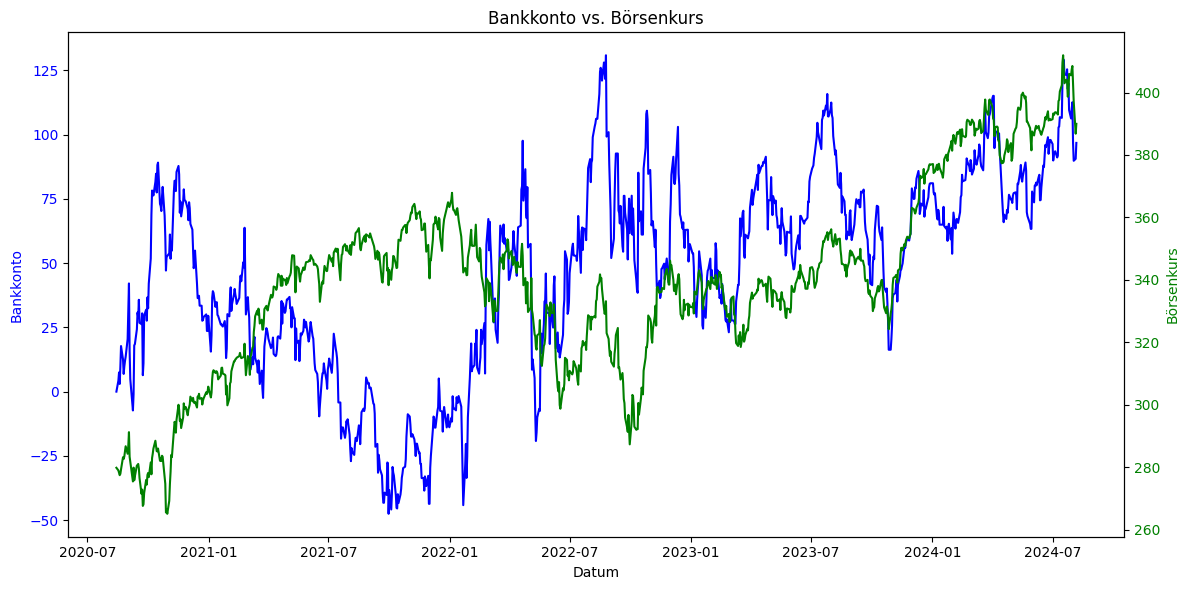

In [65]:
for _ in range(1000):
    do_one_day()
print(log_df.to_string(index=False))
visualize_results(log_df)